In [ ]:
pip install yfinance

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
import yfinance as yfin
yfin.pdr_override()

In [ ]:
start = '2015-09-01'
end = '2023-03-02'

df = pdr.get_data_yahoo('LTC-USD', start, end)
df.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-09-01,2.84742,2.87549,2.80563,2.82001,2.82001,1376040
2015-09-02,2.81981,2.82813,2.75730,2.79545,2.79545,2423010
2015-09-03,2.79669,2.80446,2.57997,2.63314,2.63314,2210590
2015-09-04,2.63814,2.72467,2.63334,2.70112,2.70112,1441530
2015-09-05,2.70205,2.94305,2.66153,2.91954,2.91954,2666820


In [ ]:
df = df.reset_index()
df = df.drop(['Date','Adj Close'], axis = 1)

In [ ]:
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))

In [ ]:
data_training_arr = scaler.fit_transform(data_training)
data_training_arr
data_training_arr.shape

(1917, 1)

In [ ]:
x_train = []
y_train = []

In [ ]:
for i in range(100, data_training_arr.shape[0]):
  x_train.append(data_training_arr[i-100: i])
  y_train.append(data_training_arr[i, 0])

In [ ]:
x_train = np.array(x_train)

In [ ]:
y_train = np.array(y_train)

In [ ]:
from keras.layers import Dense, Dropout, LSTM, GRU, Bidirectional
from keras.optimizers import SGD
from keras.models import Sequential
model = Sequential()

In [ ]:

regressorGRU = Sequential()

regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(x_train.shape[1],1), activation='tanh'))


regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(Dense(units=1))

In [ ]:


regressorGRU.compile(optimizer=SGD(lr=0.01, decay=1e-7, momentum=0.9, nesterov=False), loss='mean_squared_error')



regressorGRU.fit(x_train, y_train, epochs=5, batch_size=150)

/usr/local/lib/python3.9/dist-packages/keras/optimizers/optimizer_v2/gradient_descent.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/5
13/13 [==============================] - 13s 341ms/step - loss: 0.0116
Epoch 2/5
13/13 [==============================] - 4s 324ms/step - loss: 0.0068
Epoch 3/5
13/13 [==============================] - 5s 404ms/step - loss: 0.0036
Epoch 4/5
13/13 [==============================] - 4s 325ms/step - loss: 0.0022
Epoch 5/5
13/13 [==============================] - 5s 355ms/step - loss: 0.0015


In [ ]:
past_100 = data_training.tail(100)
final_df = past_100.append(data_testing, ignore_index = True)
input_data = scaler.fit_transform(final_df)
x_test =[]
y_test = []

for i in range(100, input_data.shape[0]):
  x_test.append(input_data[i-100: i])
  y_test.append(input_data[i, 0])
x_test, y_test = np.array(x_test), np.array(y_test)

<ipython-input-16-c8878171e6f6>:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final_df = past_100.append(data_testing, ignore_index = True)


In [ ]:
predicted_with_gru = regressorGRU.predict(x_test)
# predicted_with_gru = scaler.inverse_transform(predicted_with_gru)



26/26 [==============================] - 1s 23ms/step


In [ ]:
scaler.scale_

array([0.00291211])

In [ ]:
scale_factor = 1/0.00291211

In [ ]:
y_test = y_test * scale_factor
predicted_with_gru = predicted_with_gru * scale_factor

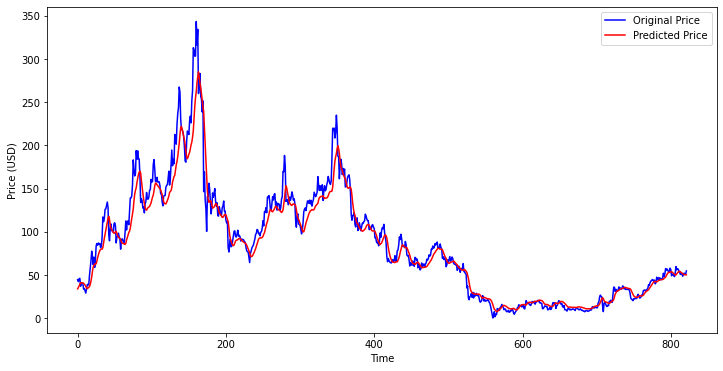

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label = 'Original Price')
plt.plot(predicted_with_gru , 'r' , label = 'Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend(loc='best')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt
rmse = sqrt(mean_squared_error(y_test, predicted_with_gru))
print('Test RMSE: %f' % rmse)

Test RMSE: 15.390722


In [ ]:
def MAPE(Y_actual,Y_Predicted):
    mape = np.mean(np.abs((Y_actual - Y_Predicted)/Y_actual))*100
    return mape

In [ ]:
LR_MAPE= MAPE(y_test,predicted_with_gru)
print("MAPE: ",LR_MAPE)

MAPE:  236.5268447015579
